In [1]:
import os
import random
from PIL import Image
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, callbacks,regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from copy import deepcopy
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()

In [2]:
#pbmを使うならこっち
data_dir = "C:/Users/torat/Desktop/sotsuken/sotsuken/True_dat_to_images_pbm"

label_dict = {
    # Mild (0)
    'AF483470.1.pbm': 0, 'EF192393.1.pbm': 0, 'EF192394.1.pbm': 0,
    'EF580923.1.pbm': 0, 'EU879915.1.pbm': 0, 'EU879916.1.pbm': 0,
    'JQ806338.1.pbm': 0, 'KF418767.1.pbm': 0, 'KR611355.1.pbm': 0,
    'KT987925.1.pbm': 0, 'LC388852.1.pbm': 0, 'LC388854.1.pbm': 0,
    'M25199.1.pbm': 0, 'MG450357.1.pbm': 0, 'Y09575.1.pbm': 0,

    # Moderate (1)
    'AF454395.1.pbm': 1, 'KF683200.1.pbm': 1, 'KJ857496.1.pbm': 1,
    'KR611360.1.pbm': 1, 'M88678.1.pbm': 1, 'X17268.1.pbm': 1,
    'GQ853461.1.pbm': 1, 'EU879913.1.pbm': 1,

    # Severe (2)
    'AJ634596.1.pbm': 2, 'AY518939.1.pbm': 2, 'AY532801.1.pbm': 2,
    'DD220185.1.pbm': 2, 'FR851463.1.pbm': 2, 'JX280944.1.pbm': 2,
    'U23060.1.pbm': 2, 'X58388.1.pbm': 2, 'X76846.1.pbm': 2,
    'X97387.1.pbm': 2, 'Y09383.1.pbm': 2, 'LC523672.1.pbm': 2,
    'LC523675.1.pbm': 2, 'LC523676.1.pbm': 2
}

labeled_pbm = list(label_dict.keys())
print(labeled_pbm)
labels = list(label_dict.values())

filepaths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".pbm")]

labels_list = [label_dict.get(os.path.basename(fp), -1) for fp in filepaths]

IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 1
num_classes = 3
learning_rate = 5e-4
epoch = 100
label_map = {0: "mild", 1: "moderate", 2: "severe"}

print(f"ラベル付きデータの数: {len(labeled_pbm)}")
print(f"全ファイル数: {len(filepaths)}")
print(f"未ラベルファイルの数: {labels_list.count(-1)}")

['AF483470.1.pbm', 'EF192393.1.pbm', 'EF192394.1.pbm', 'EF580923.1.pbm', 'EU879915.1.pbm', 'EU879916.1.pbm', 'JQ806338.1.pbm', 'KF418767.1.pbm', 'KR611355.1.pbm', 'KT987925.1.pbm', 'LC388852.1.pbm', 'LC388854.1.pbm', 'M25199.1.pbm', 'MG450357.1.pbm', 'Y09575.1.pbm', 'AF454395.1.pbm', 'KF683200.1.pbm', 'KJ857496.1.pbm', 'KR611360.1.pbm', 'M88678.1.pbm', 'X17268.1.pbm', 'GQ853461.1.pbm', 'EU879913.1.pbm', 'AJ634596.1.pbm', 'AY518939.1.pbm', 'AY532801.1.pbm', 'DD220185.1.pbm', 'FR851463.1.pbm', 'JX280944.1.pbm', 'U23060.1.pbm', 'X58388.1.pbm', 'X76846.1.pbm', 'X97387.1.pbm', 'Y09383.1.pbm', 'LC523672.1.pbm', 'LC523675.1.pbm', 'LC523676.1.pbm']
ラベル付きデータの数: 37
全ファイル数: 307
未ラベルファイルの数: 270


In [3]:
#pgmファイルならこっち

'''data_dir = "C:/Users/torat/Desktop/sotsuken/sotsuken/True_dat_to_images_pgm"

label_dict = {
    # Mild (0)
    'AF483470.1.pgm': 0, 'EF192393.1.pgm': 0, 'EF192394.1.pgm': 0,
    'EF580923.1.pgm': 0, 'EU879915.1.pgm': 0, 'EU879916.1.pgm': 0,
    'JQ806338.1.pgm': 0, 'KF418767.1.pgm': 0, 'KR611355.1.pgm': 0,
    'KT987925.1.pgm': 0, 'LC388852.1.pgm': 0, 'LC388854.1.pgm': 0,
    'M25199.1.pgm': 0, 'MG450357.1.pgm': 0, 'Y09575.1.pgm': 0,

    # Moderate (1)
    'AF454395.1.pgm': 1, 'KF683200.1.pgm': 1, 'KJ857496.1.pgm': 1,
    'KR611360.1.pgm': 1, 'M88678.1.pgm': 1, 'X17268.1.pgm': 1,
    'GQ853461.1.pgm': 1, 'EU879913.1.pgm': 1,

    # Severe (2)
    'AJ634596.1.pgm': 2, 'AY518939.1.pgm': 2, 'AY532801.1.pgm': 2,
    'DD220185.1.pgm': 2, 'FR851463.1.pgm': 2, 'JX280944.1.pgm': 2,
    'U23060.1.pgm': 2, 'X58388.1.pgm': 2, 'X76846.1.pgm': 2,
    'X97387.1.pgm': 2, 'Y09383.1.pgm': 2, 'LC523672.1.pgm': 2,
    'LC523675.1.pgm': 2, 'LC523676.1.pgm': 2
}

labeled_pbm = list(label_dict.keys())
print(labeled_pbm)
labels = list(label_dict.values())

filepaths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".pgm")]

labels_list = [label_dict.get(os.path.basename(fp), -1) for fp in filepaths]

IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 1
num_classes = 3
learning_rate = 1e-4
epoch = 100
label_map = {0: "mild", 1: "moderate", 2: "severe"}

print(f"ラベル付きデータの数: {len(labeled_pbm)}")
print(f"全ファイル数: {len(filepaths)}")
print(f"未ラベルファイルの数: {labels_list.count(-1)}")'''


'data_dir = "C:/Users/torat/Desktop/sotsuken/sotsuken/True_dat_to_images_pgm"\n\nlabel_dict = {\n    # Mild (0)\n    \'AF483470.1.pgm\': 0, \'EF192393.1.pgm\': 0, \'EF192394.1.pgm\': 0,\n    \'EF580923.1.pgm\': 0, \'EU879915.1.pgm\': 0, \'EU879916.1.pgm\': 0,\n    \'JQ806338.1.pgm\': 0, \'KF418767.1.pgm\': 0, \'KR611355.1.pgm\': 0,\n    \'KT987925.1.pgm\': 0, \'LC388852.1.pgm\': 0, \'LC388854.1.pgm\': 0,\n    \'M25199.1.pgm\': 0, \'MG450357.1.pgm\': 0, \'Y09575.1.pgm\': 0,\n\n    # Moderate (1)\n    \'AF454395.1.pgm\': 1, \'KF683200.1.pgm\': 1, \'KJ857496.1.pgm\': 1,\n    \'KR611360.1.pgm\': 1, \'M88678.1.pgm\': 1, \'X17268.1.pgm\': 1,\n    \'GQ853461.1.pgm\': 1, \'EU879913.1.pgm\': 1,\n\n    # Severe (2)\n    \'AJ634596.1.pgm\': 2, \'AY518939.1.pgm\': 2, \'AY532801.1.pgm\': 2,\n    \'DD220185.1.pgm\': 2, \'FR851463.1.pgm\': 2, \'JX280944.1.pgm\': 2,\n    \'U23060.1.pgm\': 2, \'X58388.1.pgm\': 2, \'X76846.1.pgm\': 2,\n    \'X97387.1.pgm\': 2, \'Y09383.1.pgm\': 2, \'LC523672.1.pgm\': 2,

In [4]:
def load_and_preprocess_list(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p))
        img = img.reshape(64, 64, 1)
        img = img.astype('float32')
        #img /= 255
        X.append(img)
    return np.array(X)

In [5]:
def load_and_preprocess_list_gabege(fp_list):
    X = []
    for p in fp_list:
        img = np.array(Image.open(p))
        img = img.reshape(64, 64, 1)
        img = img.astype('float32')
        img /= 1
        X.append(img)
    return np.array(X)

In [6]:
def make_model():
    model = models.Sequential()
    model.add(layers.Conv2D(16,(3,3), activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(64, 64, 1)))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(32,(3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu', kernel_regularizer = regularizers.l2(0.001)))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64, activation='relu', kernel_regularizer = regularizers.l2(0.001)))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

In [7]:
def make_128_model():
    model = models.Sequential()
    model.add(layers.Conv2D(16,(3,3), activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(128, 128, 1)))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(32,(3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu', kernel_regularizer = regularizers.l2(0.001)))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64, activation='relu', kernel_regularizer = regularizers.l2(0.001)))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

In [8]:
def origin_make_model():
    model = models.Sequential()
    model.add(layers.Conv2D(16,(3,3), activation='relu', input_shape=(64, 64, 1)))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Conv2D(32,(3,3), activation='relu'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

In [9]:
def jackknife_on_files(labeled_paths, labeled_labels, unlabeled_paths, epochs, verbose=1):
    n = len(labeled_paths)
    X_labeled = load_and_preprocess_list(labeled_paths)
    y_labeled = np.array(labeled_labels, dtype=np.int32)
    X_unlabeled = load_and_preprocess_list(unlabeled_paths)
    val_accs = []
    val_records = []

    all_preds = {os.path.basename(fp): {"True_Label": label_map.get(lb, "")}
                 for fp, lb in zip(labeled_paths + unlabeled_paths, labels_list)}

    for i in range(n):
        print(f"\nFold {i+1}/{n} ")
        #i番目のデータを検証用、それ以外を学習用
        mask = np.arange(n) != i

        x_train, y_train = X_labeled[mask], y_labeled[mask]
        x_test, y_test = X_labeled[[i]], y_labeled[[i]]

        val_name = os.path.basename(labeled_paths[i])
        val_true_label = label_map[int(y_test[0])]

        early_stop = callbacks.EarlyStopping(
            monitor='loss',
            patience=5,        # 5エポック改善しなければ止める
            restore_best_weights=True
        )


        model = make_model()
        model.compile(optimizer=optimizers.Adam(learning_rate),
                      loss=losses.SparseCategoricalCrossentropy(),
                      metrics=['sparse_categorical_accuracy'])

        #モデル学習部分
        history = model.fit(x_train, y_train,batch_size = BATCH_SIZE ,epochs=epochs, verbose=verbose, callbacks = [early_stop])



        pred_history = model.predict(x_test)
        plt.figure(figsize=(10, 6))

        results.append(history.history)
        pred_results.append([labeled_pbm[i],pred_history])





In [10]:
labeled_fullpaths = [os.path.join(data_dir, name) for name in labeled_pbm]
unlabeled_fullpaths = [fp for fp, lb in zip(filepaths, labels_list) if lb == -1]

results = []
pred_results = []
records = []
stopped_epochs = []

jackknife_on_files(labeled_fullpaths, labels, unlabeled_fullpaths, epochs=epoch, verbose=1)

img_ext = os.listdir(data_dir)
img_ext = [f.split('.')[-1] for f in img_ext if '.' in f][0]
lr_str = "{:.0e}".format(learning_rate)
output_dir = f"{num_classes}classes_epoch{epoch}_{lr_str}_{img_ext}"
os.makedirs(output_dir, exist_ok=True)

mat_dir = os.path.join(output_dir, "mat")
acc_dir = os.path.join(output_dir, "acc")
fold_loss_dir = os.path.join(output_dir, "fold_loss")

for d in [mat_dir, acc_dir, fold_loss_dir]:
    os.makedirs(d, exist_ok=True)


Fold 1/37 
Epoch 1/100


C:\Users\torat\Desktop\sotsuken\sotsuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3265 - sparse_categorical_accuracy: 0.3333
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2388 - sparse_categorical_accuracy: 0.4167
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2427 - sparse_categorical_accuracy: 0.2500
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1933 - sparse_categorical_accuracy: 0.5000
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1052 - sparse_categorical_accuracy: 0.5556
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1589 - sparse_categorical_accuracy: 0.5278
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0182 - sparse_categorical_accuracy: 0.7500
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0336 - sparse_categorical_accuracy: 0.6111
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9811 - sparse_categorical_accuracy: 0.5833
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0174 - sparse_

C:\Users\torat\AppData\Local\Temp\ipykernel_27784\670171200.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2948 - sparse_categorical_accuracy: 0.3889
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2246 - sparse_categorical_accuracy: 0.4167
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1653 - sparse_categorical_accuracy: 0.5000
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1862 - sparse_categorical_accuracy: 0.3611
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1555 - sparse_categorical_accuracy: 0.4167
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1195 - sparse_categorical_accuracy: 0.6111
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0911 - sparse_categorical_accuracy: 0.5833
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0512 - sparse_categorical_accuracy: 0.5833
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0765 - sparse_categorical_accuracy: 0.5833
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0189 - sparse_

...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [11]:
for i, r in enumerate(results):
    plt.figure(figsize=(8, 5))
    plt.plot(r["loss"], label="Train Loss", color="blue")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {i+1} - Train Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(fold_loss_dir, f"fold_{i+1}_loss.png"))
    plt.close()

for i, r in enumerate(results):
    plt.figure(figsize=(8, 5))
    plt.plot(r["sparse_categorical_accuracy"], label="Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim([0, 1])
    plt.title(f"Fold {i+1} - Train Accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(acc_dir, f"fold_{i+1}_accuracy.png"))
    plt.close()


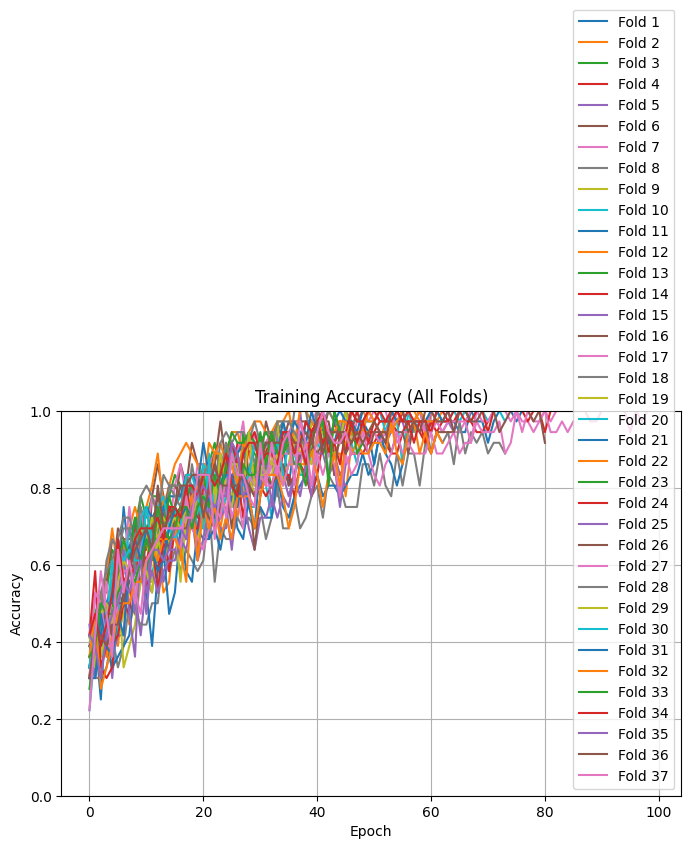

In [12]:
plt.figure(figsize=(8, 5))
for i in range(len(results)):
    plt.plot(results[i]['sparse_categorical_accuracy'], label=f'Fold {i+1}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.title("Training Accuracy (All Folds)")
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig(os.path.join(acc_dir, "all_folds_accuracy.png"))
plt.show()
plt.close()

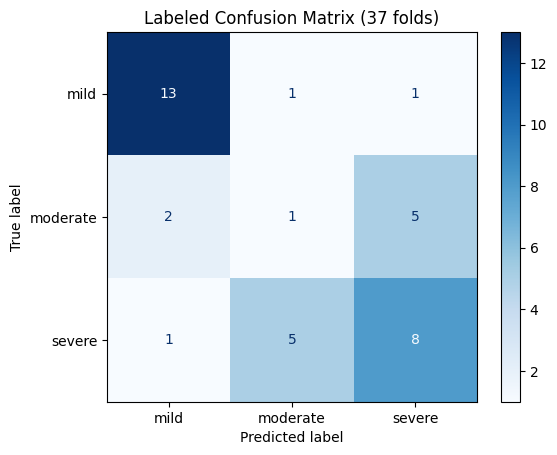

In [13]:
#print(pred_results)
pred_labels = []
true_labels = []
for i in range(len(pred_results)):
    pre = pred_results[i][1].tolist()
    pre = pre[0]
    pred_labels.append(pre.index(max(pre)))
    true_labels.append(label_dict[pred_results[i][0]])

fixed_labels = ["mild","moderate", "severe"]
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fixed_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Labeled Confusion Matrix (37 folds)")
plt.savefig(os.path.join(mat_dir, "confusion_matrix.png"))
plt.show()
plt.close()


In [14]:
label_map = {0: "mild", 1: "moderate", 2: "severe"}

misclassified = []

for i in range(len(pred_results)):
    filename = pred_results[i][0]           # ファイル名（例: 'AF483470.1.pbm'）
    probs = pred_results[i][1][0]           # 予測確率 [p(mild), p(moderate), p(severe)]
    pred_label = int(np.argmax(probs))      # 予測ラベル (0,1,2)
    true_label = int(label_dict[filename])  # 真のラベル (0,1,2)

    if pred_label != true_label:  # 誤分類のみ抽出
        misclassified.append({
            "PBM_Name": filename,
            "True_Label": label_map[true_label],
            "Pred_Label": label_map[pred_label],
            "Prob_mild": probs[0],
            "Prob_moderate": probs[1],
            "Prob_severe": probs[2]
        })

# DataFrameで出力
df_mis = pd.DataFrame(misclassified)
print("=== 誤分類されたサンプル ===")
print(df_mis)
df_mis.to_csv("misclassified_samples.csv", index=False)

=== 誤分類されたサンプル ===
          PBM_Name True_Label Pred_Label  Prob_mild  Prob_moderate  \
0   EF192394.1.pbm       mild   moderate   0.204474       0.456106   
1   JQ806338.1.pbm       mild     severe   0.003955       0.045351   
2   AF454395.1.pbm   moderate     severe   0.045956       0.063656   
3   KF683200.1.pbm   moderate     severe   0.005885       0.001753   
4   KJ857496.1.pbm   moderate       mild   0.469590       0.301984   
5   KR611360.1.pbm   moderate       mild   0.996199       0.000315   
6     X17268.1.pbm   moderate     severe   0.000040       0.000774   
7   GQ853461.1.pbm   moderate     severe   0.004381       0.017561   
8   EU879913.1.pbm   moderate     severe   0.165210       0.040141   
9   AY532801.1.pbm     severe   moderate   0.019235       0.968254   
10  FR851463.1.pbm     severe       mild   0.813188       0.151901   
11  JX280944.1.pbm     severe   moderate   0.091452       0.538942   
12    X76846.1.pbm     severe   moderate   0.154518       0.557422   
1

Epoch 1/100


C:\Users\torat\Desktop\sotsuken\sotsuken\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2771 - sparse_categorical_accuracy: 0.4054
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2480 - sparse_categorical_accuracy: 0.3784
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2182 - sparse_categorical_accuracy: 0.4595
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1797 - sparse_categorical_accuracy: 0.4595
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1523 - sparse_categorical_accuracy: 0.4324
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1834 - sparse_categorical_accuracy: 0.5405
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1344 - sparse_categorical_accuracy: 0.6216
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1104 - sparse_categorical_accuracy: 0.5676
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0659 - sparse_categorical_accuracy: 0.6216
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0423 - sparse_

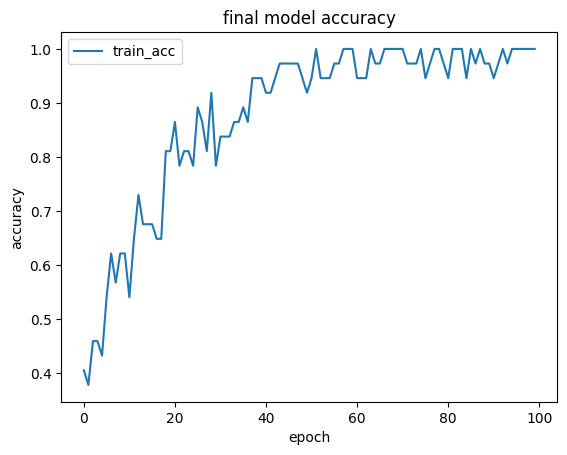

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Saved CSV: 3classes_epoch100_1e-04_pbm.csv
finish


In [15]:
final_early_stop = callbacks.EarlyStopping(
    monitor='loss',
    patience=5,        # 10エポック改善しなければ止める
    restore_best_weights=True
)

final_model = make_model()
final_model.compile(optimizer=optimizers.Adam(learning_rate),
                    loss=losses.SparseCategoricalCrossentropy(),
                    metrics=['sparse_categorical_accuracy'])

x_all = load_and_preprocess_list(labeled_fullpaths)
y_all = np.array(labels, dtype = np.int32)
final_history = final_model.fit(x_all, y_all,batch_size = BATCH_SIZE,epochs = epoch,verbose=1)

plt.plot(final_history.history["sparse_categorical_accuracy"], label="train_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("final model accuracy")
plt.legend()
plt.savefig(os.path.join(acc_dir, "acc.png"))
plt.show()
plt.close()

final_model.save("jackknife_PSTVd_model.keras")

X_unlabeled = load_and_preprocess_list(unlabeled_fullpaths)

unlabeled_preds = final_model.predict(X_unlabeled)

pred_classes = np.argmax(unlabeled_preds, axis=1)
pred_labels = [label_map[c] for c in pred_classes]

df_pred = pd.DataFrame({
    "PBM_Name": [os.path.basename(fp) for fp in unlabeled_fullpaths],
    "Pred_Sym_Severity": pred_labels
})

csv_name = f"{num_classes}classes_epoch{epoch}_{lr_str}_{img_ext}.csv"
df_pred.to_csv(csv_name, index=False)
print("Saved CSV:", csv_name)
print("finish")
